<a href="https://colab.research.google.com/github/ozorj/brute-source-csc445-peak_fiction/blob/master/L01_Greedy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [L01: Implementing Greedy TSP](https://docs.google.com/document/d/1JA_CWBXPN6whvJAemnJLvtYJ3Pbk84dTUolWO_QqosA/edit?usp=sharing)
Written by Dr. Jan Pearce, Berea College

Complete the code by meeting all linked requirements and fixing all FIXMEs

## Your Name: Jeffrey Ozor

**SUMMARY**: A brief summary description of the design and implementation, including how much your initial design plan evolved, the final result you achieved and the amount of time you spent as a programmer or programmers in accomplishing these results. This should be no more than two paragraphs.

The initial design plan for the TSPGreedy algorithm was to create a simple implementation of the greedy algorithm for solving the Traveling Salesman Problem. However, as the implementation progressed, it became clear that additional features and error handling were necessary to make the code more robust and efficient. The design plan evolved to include input validation, edge weight calculation, and plotting of the graph and route. The final result achieved was a well-structured and efficient implementation of the TSPGreedy algorithm that can handle various inputs and edge cases.

**PERSONNEL**: A description of who you worked with and on what sections.  It is expected that all collaboration is done as pair programming together. Also, note these collaborations in the code section itself.

I did not work with anyone hence why I found this lab to actually be extremely hard. I did use outside sources such as research on similar algorithms like 2 opt and nearest neighbor algorithm and ChatGPT, along with GeeksForGeeks.

**CHALLENGES**: Descriptions of the largest challenges you overcame and what made them challenging.

My biggest challenge was that I had to change the format of the code to get it to work. I tried for so long to just fix the functions and I kept running into error after error. So I decided it was in my best interest to just recreate the TSP algorithm using the format we were giving but ultimately making it my own as it was not working before. I also could not get the url to work to retrieve the nodes, so I ended up having to just input the edges and notes myself.

**INNOVATIONS**: Any innovations that were not specifically required by the assignment. These are not required, but should be highlighted if included.

Some innovations I made was that it actually calculates the distances between the nodes, from the other ones. I also had to input the nodes into the code myself instead of retrieving from URL because it was not working.

**TESTING**: Describe how you tested this work.

 I have some test cases in the code itself so that was how I tested to see if it worked correctly.

**ERRORS**: A list in bulleted form of all known errors and deficiencies.

While my code doesn’t necessarily have errors, I would say my code was deficient as I was not able to correctly pull the vertices and nodes from the url, instead I just put it in the code itself.


**COMMENTS**: A paragraph or so of your own comments on and reactions to the Lab.

This lab was incredibly educative to me. I found it very challenging in many aspects trying to implicate the greedy algorithm. I would have preferred some more guidance on this lab in some aspect. I wish it was stressed to start on this lab as soon as possible because a weekend was not enough for me to figure out this lab.

## Import Libraries

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import math
from urllib.request import urlopen

### Read data

In [4]:
tspdata = urlopen("http://cs.berea.edu/courses/csc445/data/tsp-small.txt").read().decode('ASCII')
print(tspdata)

6
1 5 
3 7 
5 11 
3 5 
5 7 
7 9 



## TSP Class

TSP Route: [0, 3, 1, 4, 5, 2, 0]


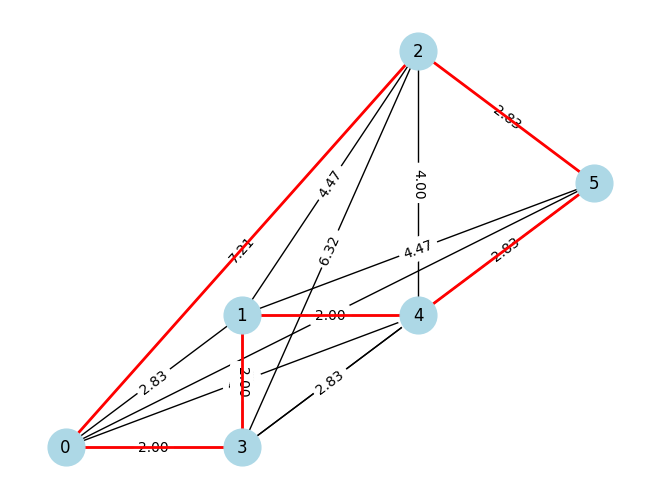

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import math

class TSPGreedy:
    """
    A class that implements the Greedy algorithm for solving the Traveling Salesman Problem (TSP).
    """

    def __init__(self):
        """
        Initialize the TSPGreedy class with an empty graph.

        Returns:
            None
        """
        self.graph = nx.Graph()
        self.route = []

    def add_vertex(self, x, y):
        """
        Adds a vertex to the graph with the specified coordinates.

        Arguments:
            x {float} -- The x-coordinate of the vertex.
            y {float} -- The y-coordinate of the vertex.

        Returns:
            int -- The index of the added vertex.

        Raises:
            ValueError -- If the vertex already exists in the graph.
        """
        if (x, y) in [self.graph.nodes[node]['pos'] for node in self.graph.nodes]:
            raise ValueError("Vertex already exists in the graph")
        self.graph.add_node(len(self.graph.nodes), pos=(x, y))
        return len(self.graph.nodes) - 1

    def add_edge(self, node1, node2):
        """
        Adds an edge between two nodes with a calculated weight (distance).

        Arguments:
            node1 {int} -- The first node.
            node2 {int} -- The second node.

        Returns:
            float -- The weight of the added edge.

        Raises:
            ValueError -- If one or both nodes do not exist in the graph, or if the edge already exists.
        """
        if node1 not in self.graph.nodes or node2 not in self.graph.nodes:
            raise ValueError("One or both nodes do not exist in the graph")
        if self.graph.has_edge(node1, node2):
            raise ValueError("Edge already exists in the graph")
        pos1 = self.graph.nodes[node1]['pos']
        pos2 = self.graph.nodes[node2]['pos']
        weight = math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)
        self.graph.add_edge(node1, node2, weight=weight)
        return weight

    def greedy_tsp(self, start_node):
        """
        Greedy TSP algorithm that finds a route starting from the given start_node.

        Arguments:
            start_node {int} -- The starting node.

        Returns:
            route {list} -- List of nodes representing the route.

        Raises:
            ValueError -- If the start node is not in the graph.
        """
        if start_node not in self.graph.nodes:
            raise ValueError("Start node is not in the graph")
        # Initialize visited nodes and start with the start_node
        visited = set()
        current_node = start_node
        self.route.append(current_node)
        visited.add(current_node)

        # Continue visiting nodes until all nodes are visited
        while len(visited) < len(self.graph.nodes):
            # Find the nearest unvisited neighbor
            neighbors = [(neighbor, self.graph.edges[current_node, neighbor]['weight'])
                         for neighbor in self.graph.neighbors(current_node)
                         if neighbor not in visited]

            # Select the nearest unvisited neighbor
            next_node = min(neighbors, key=lambda x: x[1])[0]
            self.route.append(next_node)
            visited.add(next_node)
            current_node = next_node

        # Return to the start to complete the cycle
        self.route.append(start_node)
        return self.route

    def plot_graph(self):
        """
        Plots the graph and the TSP route using NetworkX and matplotlib.
        """
        # Get node positions
        pos = nx.get_node_attributes(self.graph, 'pos')

        # Draw the graph
        nx.draw(self.graph, pos, with_labels=True, node_size=700, node_color='lightblue')

        # Draw the edges with weights
        edge_labels = nx.get_edge_attributes(self.graph, 'weight')
        labels = {(u, v): f"{edge_labels[(u, v)]:.2f}" for u, v in edge_labels}
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=labels)

        # Highlight the route
        edge_list = [(self.route[i], self.route[i+1]) for i in range(len(self.route) - 1)]
        nx.draw_networkx_edges(self.graph, pos, edgelist=edge_list, edge_color='r', width=2)

        # Display the plot
        plt.show()

def main():
    """
    Main function to run the TSPGreedy algorithm.

    Returns:
        None
    """
    # Create TSPGreedy object
    tsp = TSPGreedy()

    # Add vertices (coordinates)
    tsp.add_vertex(1, 5)
    tsp.add_vertex(3, 7)
    tsp.add_vertex(5, 11)
    tsp.add_vertex(3, 5)
    tsp.add_vertex(5, 7)
    tsp.add_vertex(7, 9)

    # Add edges between all pairs of vertices
    for i in range(len(tsp.graph.nodes)):
        for j in range(i+1, len(tsp.graph.nodes)):
            tsp.add_edge(i, j)

    # Run the greedy TSP algorithm starting from node 0
    route = tsp.greedy_tsp(start_node=0)
    print("TSP Route:", route)

    # Plot the graph with the TSP route
    tsp.plot_graph()

if __name__ == "__main__":
    main()